# 1. Install required libraries

In [ ]:
!pip install torch torchvision torchaudio torch-geometric pandas numpy
!pip install torch torchvision torchaudio torch-geometric pandas openpyxl numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


# 2. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv


# 3. Load Dataset

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
print("Original Data Shape:", df.shape)
df.head()


Saving Students_Performance_data_set.xlsx to Students_Performance_data_set.xlsx
Original Data Shape: (1194, 32)


,Student ID,University Admission year,Gender,Age,H.S.C passing year,program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,S-1,2018,Male,24,2016,BSCS,1,Yes,No,3,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,S-2,2021,Male,22,2020,BSCS,4,Yes,Yes,3,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,S-3,2020,Female,21,2019,BSCS,5,No,No,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,S-4,2021,Male,20,2020,BSCS,4,Yes,No,1,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,S-5,2021,Male,22,2019,BSCS,4,Yes,No,3,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


# 4. Data Cleaning & Preprocessing

In [ ]:
# Load Excel file
df = pd.read_excel('/content/Students_Performance_data_set.xlsx')

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\n','')
df.columns = df.columns.str.replace(' ','_')
df.columns = df.columns.str.replace('?','')
print("Columns after cleaning:", df.columns.tolist())

# Fill missing values
df = df.fillna(0)

# Convert Yes/No columns to 1/0
yes_no_cols = [
    'Do_you_have_meritorious_scholarship_',
    'Do_you_use_University_transportation',
    'Do_you_use_smart_phone',
    'Do_you_have_personal_Computer',
    'Are_you_engaged_with_any_co-curriculum_activities',
    'Do_you_have_any_health_issues',
    'Do_you_have_any_physical_disabilities',
    'Did_you_ever_fall_in_probation',
    'Did_you_ever_got_suspension'
]

for col in yes_no_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes':1, 'No':0})
    else:
        print(f"Warning: Column '{col}' not found in dataset")

# Encode categorical columns as integer indices
cat_cols = [
    'program',
    'What_is_your_preferable_learning_mode',
    'What_are_the_skills_do_you_have_',
    'What_is_you_interested_area',
    'What_is_your_relationship_status',
    'With_whom_you_are_living_with'
]

cat_indices = {}
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        df[col+'_idx'] = df[col].cat.codes
        cat_indices[col] = len(df[col].cat.categories)
    else:
        print(f"Warning: Column '{col}' not found in dataset")

# Optional: check
print("✅ Data Cleaning & Encoding Complete")
print(df.head())
print("Categorical indices:", cat_indices)


Columns after cleaning: ['Student_ID', 'University_Admission_year', 'Gender', 'Age', 'H.S.C_passing_year', 'program', 'Current_Semester', 'Do_you_have_meritorious_scholarship_', 'Do_you_use_University_transportation', 'How_many_hour_do_you_study_daily', 'How_many_times_do_you_seat_for_study_in_a_day', 'What_is_your_preferable_learning_mode', 'Do_you_use_smart_phone', 'Do_you_have_personal_Computer', 'How_many_hour_do_you_spent_daily_in_social_media', 'Status_of_your_English_language_proficiency', 'Average_attendance_on_class', 'Did_you_ever_fall_in_probation', 'Did_you_ever_got_suspension', 'Do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems', 'What_are_the_skills_do_you_have_', 'How_many_hour_do_you_spent_daily_on_your_skill_development', 'What_is_you_interested_area', 'What_is_your_relationship_status', 'Are_you_engaged_with_any_co-curriculum_activities', 'With_whom_you_are_living_with', 'Do_you_have_any_health_issues', 'What_was_your_previous_SGPA', 'Do_you_hav

# 5. Assign Tutor / Tutee Roles

In [ ]:
cgpa_col = 'What_is_your_current_CGPA'
prob_col = 'Did_you_ever_fall_in_probation'

df['role'] = ['Tutor' if (cgpa >= 3.0 and prob == 0) else 'Tutee'
              for cgpa, prob in zip(df[cgpa_col], df[prob_col])]

print(df['role'].value_counts())
print(df[['Student_ID', cgpa_col, prob_col, 'role']].head())


role
Tutor    704
Tutee    490
Name: count, dtype: int64
  Student_ID  What_is_your_current_CGPA  Did_you_ever_fall_in_probation   role
0        S-1                       3.15                               0  Tutor
1        S-2                       3.15                               1  Tutee
2        S-3                       3.15                               0  Tutor
3        S-4                       3.15                               0  Tutor
4        S-5                       3.15                               0  Tutor


# 6. Prepare Features

In [ ]:
import pandas as pd
import numpy as np

# 1️⃣ Numeric columns to use as features
numeric_cols = [
    'What_is_your_current_CGPA',
    'What_was_your_previous_SGPA',
    'How_many_hour_do_you_study_daily',
    'How_many_times_do_you_seat_for_study_in_a_day',
    'Average_attendance_on_class',
    'How_many_hour_do_you_spent_daily_on_your_skill_development',
    'How_many_hour_do_you_spent_daily_in_social_media'
]

# 2️⃣ Yes/No numeric columns (already converted to 0/1)
yes_no_cols = [
    'Do_you_have_meritorious_scholarship_',
    'Do_you_use_University_transportation',
    'Do_you_use_smart_phone',
    'Do_you_have_personal_Computer',
    'Are_you_engaged_with_any_co-curriculum_activities',
    'Do_you_have_any_health_issues',
    'Do_you_have_any_physical_disabilities',
    'Did_you_ever_fall_in_probation',
    'Did_you_ever_got_suspension'
]

# 3️⃣ Categorical indices created earlier
cat_idx_cols = [col for col in df.columns if col.endswith('_idx')]

# 4️⃣ Combine all feature columns
feature_cols = numeric_cols + yes_no_cols + cat_idx_cols

# 5️⃣ Create feature matrix (numpy array)
X = df[feature_cols].values
print("Feature matrix shape:", X.shape)

# Optional: Check first row
print("Example feature vector for first student:")
print(X[0])


Feature matrix shape: (1194, 22)
Example feature vector for first student:
[3.15 2.68 3 2 90 2 5 1 0 1 1 1 0.0 0 0 0 0 0 44 7 4 0]


# 7. Graph Databases using Neo4j

In [ ]:
!pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 6.3 MB/s eta 0:00:00


In [ ]:
import neo4j
print(neo4j.__version__)


6.1.0


In [ ]:
from neo4j import GraphDatabase

# === 1️⃣ Connect to Neo4j AuraDB ===
NEO4J_URI = "neo4j+s://1ae5dd78.databases.neo4j.io"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "Qfquqk94yxyCZkRg2hkI67kcJUmd0jg_RMZ4Gv_eRnQ"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

# === 2️⃣ Node creation function ===
def create_student_node(tx, student, feature_cols):
    # Prepare all features as properties
    props = {col: student[col] for col in feature_cols}
    props['role'] = student['role']   # optional
    props['id'] = student['Student_ID']

    tx.run("""
        MERGE (s:Student {id: $id})
        SET s += $props
    """, id=student['Student_ID'], props=props)

# === 3️⃣ Create all student nodes ===
feature_cols = numeric_cols + yes_no_cols + cat_idx_cols  # your features
with driver.session() as session:
    for _, student in df.iterrows():
        session.execute_write(create_student_node, student, feature_cols)

print("✅ Nodes created successfully in Neo4j")

✅ Nodes created successfully in Neo4j


In [ ]:

# 2️⃣ BULK EDGE CREATION FUNCTION
def bulk_create_tutor_tutee_edges(tx, edges):
    tx.run("""
        UNWIND $edges AS e
        MATCH (tutor:Student {id: e.tutor_id})
        MATCH (tutee:Student {id: e.tutee_id})
        MERGE (tutor)-[r:POTENTIAL_MATCH]->(tutee)
        SET r.same_program  = e.same_program,
            r.same_skill    = e.same_skill,
            r.same_interest = e.same_interest,
            r.weight        = 1.0
    """, edges=edges)

# 3️⃣ PREPARE EDGE DATA
tutors = df[df['role'] == 'Tutor']
tutees = df[df['role'] == 'Tutee']

print(f"Number of Tutors : {len(tutors)}")
print(f"Number of Tutees : {len(tutees)}")

edges_to_create = []

for _, tutor in tutors.iterrows():
    tutor_program  = tutor['program']
    tutor_skill    = tutor['What_are_the_skills_do_you_have_']
    tutor_interest = tutor['What_is_you_interested_area']

    for _, tutee in tutees.iterrows():
        same_program  = tutor_program == tutee['program']
        same_skill    = tutor_skill == tutee['What_are_the_skills_do_you_have_']
        same_interest = tutor_interest == tutee['What_is_you_interested_area']

        if same_program or same_skill or same_interest:
            edges_to_create.append({
                "tutor_id": tutor['Student_ID'],
                "tutee_id": tutee['Student_ID'],
                "same_program": same_program,
                "same_skill": same_skill,
                "same_interest": same_interest
            })

print(f"Total POTENTIAL_MATCH edges to create: {len(edges_to_create)}")

# 4️⃣ FAST BATCH INSERTION
batch_size = 5000

with driver.session() as session:
    for i in range(0, len(edges_to_create), batch_size):
        batch = edges_to_create[i:i + batch_size]

        session.execute_write(
            bulk_create_tutor_tutee_edges,
            batch
        )

        print(f"✅ Batch {i // batch_size + 1} inserted | Size: {len(batch)}")

# 5️⃣ CLEANUP
driver.close()

print("🚀 ALL POTENTIAL_MATCH EDGES CREATED SUCCESSFULLY")


Number of Tutors : 704
Number of Tutees : 490
Total POTENTIAL_MATCH edges to create: 344960
✅ Batch 1 inserted | Size: 5000
✅ Batch 2 inserted | Size: 5000
✅ Batch 3 inserted | Size: 5000
✅ Batch 4 inserted | Size: 5000
✅ Batch 5 inserted | Size: 5000
✅ Batch 6 inserted | Size: 5000
✅ Batch 7 inserted | Size: 5000
✅ Batch 8 inserted | Size: 5000
✅ Batch 9 inserted | Size: 5000
✅ Batch 10 inserted | Size: 5000
✅ Batch 11 inserted | Size: 5000
✅ Batch 12 inserted | Size: 5000
✅ Batch 13 inserted | Size: 5000
✅ Batch 14 inserted | Size: 5000
✅ Batch 15 inserted | Size: 5000
✅ Batch 16 inserted | Size: 5000
✅ Batch 17 inserted | Size: 5000
✅ Batch 18 inserted | Size: 5000
✅ Batch 19 inserted | Size: 5000
✅ Batch 20 inserted | Size: 5000
✅ Batch 21 inserted | Size: 5000
✅ Batch 22 inserted | Size: 5000
✅ Batch 23 inserted | Size: 5000
✅ Batch 24 inserted | Size: 5000
✅ Batch 25 inserted | Size: 5000
✅ Batch 26 inserted | Size: 5000
✅ Batch 27 inserted | Size: 5000
✅ Batch 28 inserted | Size

# 8. GraphSAGE Embedding & Tutor-Tutee Matching

Epoch 01 | Loss 697.4962 | Train 50.00% | Val 50.00%
Epoch 02 | Loss 324.5602 | Train 49.99% | Val 50.00%
Epoch 03 | Loss 134.8196 | Train 44.94% | Val 44.63%
Epoch 04 | Loss 111.1773 | Train 24.36% | Val 24.40%
Epoch 05 | Loss 84.0851 | Train 44.74% | Val 44.40%
Epoch 06 | Loss 104.4338 | Train 50.00% | Val 50.00%
Epoch 07 | Loss 100.6372 | Train 50.00% | Val 50.00%
Epoch 08 | Loss 81.6324 | Train 50.00% | Val 50.00%
Epoch 09 | Loss 60.8030 | Train 50.00% | Val 50.00%
Epoch 10 | Loss 45.4502 | Train 50.00% | Val 50.00%
Epoch 11 | Loss 36.0817 | Train 50.00% | Val 50.00%
Epoch 12 | Loss 31.7885 | Train 50.00% | Val 50.00%
Epoch 13 | Loss 29.9114 | Train 49.99% | Val 50.00%
Epoch 14 | Loss 29.0544 | Train 49.90% | Val 49.86%
Epoch 15 | Loss 28.0655 | Train 49.83% | Val 49.81%
Epoch 16 | Loss 26.2215 | Train 49.72% | Val 49.71%
Epoch 17 | Loss 23.4659 | Train 48.98% | Val 48.87%
Epoch 18 | Loss 20.2568 | Train 47.36% | Val 47.23%
Epoch 19 | Loss 17.2467 | Train 44.75% | Val 44.47%
Epoch 

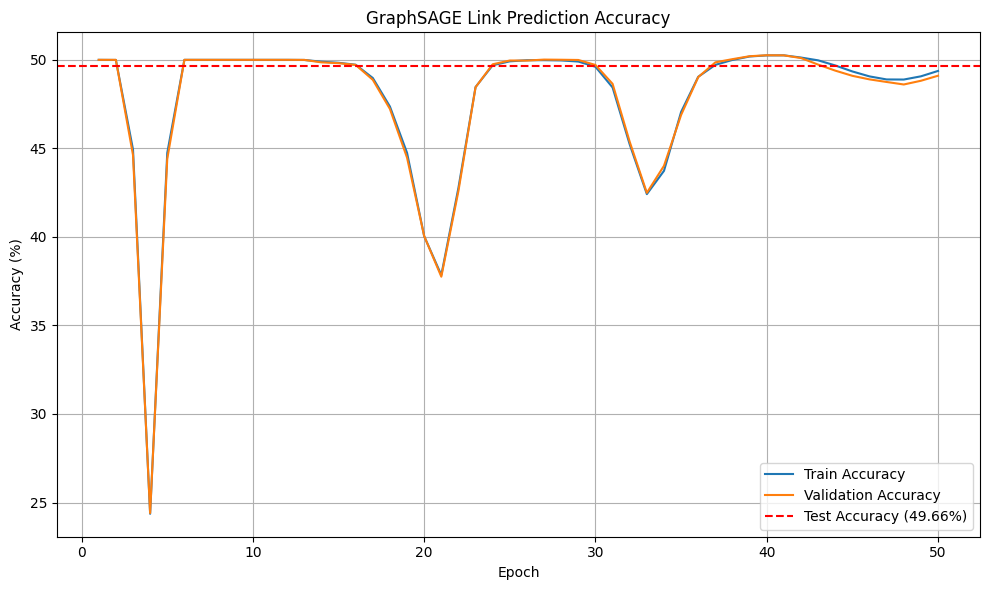

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import train_test_split
from neo4j import GraphDatabase

# -------------------- Neo4j Connection --------------------
NEO4J_URI = "neo4j+s://1ae5dd78.databases.neo4j.io"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "Qfquqk94yxyCZkRg2hkI67kcJUmd0jg_RMZ4Gv_eRnQ"

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD),
    max_connection_pool_size=50
)

# -------------------- Feature Columns --------------------
numeric_cols = [
    'What_is_your_current_CGPA',
    'What_was_your_previous_SGPA',
    'How_many_hour_do_you_study_daily',
    'How_many_times_do_you_seat_for_study_in_a_day',
    'Average_attendance_on_class',
    'How_many_hour_do_you_spent_daily_on_your_skill_development',
    'How_many_hour_do_you_spent_daily_in_social_media'
]

yes_no_cols = [
    'Do_you_have_meritorious_scholarship_',
    'Do_you_use_University_transportation',
    'Do_you_use_smart_phone',
    'Do_you_have_personal_Computer',
    'Are_you_engaged_with_any_co-curriculum_activities',
    'Do_you_have_any_health_issues',
    'Do_you_have_any_physical_disabilities',
    'Did_you_ever_fall_in_probation',
    'Did_you_ever_got_suspension'
]

cat_idx_cols = [
    'program_idx',
    'What_is_your_preferable_learning_mode_idx'
]

feature_cols = numeric_cols + yes_no_cols + cat_idx_cols

# -------------------- Load Nodes --------------------
def get_nodes(tx):
    query = f"""
    MATCH (s:Student)
    RETURN s.id AS id, s.role AS role,
           {", ".join([f"s.`{c}` AS `{c}`" for c in feature_cols])}
    """
    return pd.DataFrame([r.data() for r in tx.run(query)])

with driver.session() as session:
    df_nodes = session.execute_read(get_nodes)

X_np = df_nodes[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values
X = torch.tensor(X_np, dtype=torch.float)

id_to_idx = {sid: i for i, sid in enumerate(df_nodes["id"])}

# -------------------- Load Edges --------------------
def get_edges(tx):
    query = """
    MATCH (t:Student)-[:POTENTIAL_MATCH]->(u:Student)
    RETURN t.id AS src, u.id AS dst
    """
    return [(r["src"], r["dst"]) for r in tx.run(query)]

with driver.session() as session:
    edges = session.execute_read(get_edges)

edge_list = [[id_to_idx[s], id_to_idx[d]] for s, d in edges]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# -------------------- Train / Val / Test Split --------------------
edges_np = np.array(edge_list)
train_e, test_e = train_test_split(edges_np, test_size=0.2, random_state=42)
train_e, val_e = train_test_split(train_e, test_size=0.1, random_state=42)

train_edge_index = torch.tensor(train_e, dtype=torch.long).t().contiguous()

# -------------------- GraphSAGE Model --------------------
class GraphSAGE(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, 64)
        self.conv2 = SAGEConv(64, 32)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        return self.conv2(x, edge_index)

model = GraphSAGE(X.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# -------------------- Link Prediction Utils --------------------
def edge_logits(emb, edges):
    edges = torch.tensor(edges, dtype=torch.long)
    return (emb[edges[:, 0]] * emb[edges[:, 1]]).sum(dim=1)

def accuracy(emb, pos_edges):
    neg_edges = np.random.randint(0, emb.shape[0], (len(pos_edges), 2))
    pos = torch.sigmoid(edge_logits(emb, pos_edges)) > 0.5
    neg = torch.sigmoid(edge_logits(emb, neg_edges)) < 0.5
    return (pos.sum() + neg.sum()).item() / (2 * len(pos_edges))

# -------------------- Training Loop --------------------
train_acc_list = []
val_acc_list = []

for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    emb = model(X, train_edge_index)

    pos_out = edge_logits(emb, train_e)
    neg_edges = np.random.randint(0, X.shape[0], (len(train_e), 2))
    neg_out = edge_logits(emb, neg_edges)

    loss = F.binary_cross_entropy_with_logits(
        torch.cat([pos_out, neg_out]),
        torch.cat([torch.ones_like(pos_out), torch.zeros_like(neg_out)])
    )

    loss.backward()
    optimizer.step()

    model.eval()
    train_acc = accuracy(emb.detach(), train_e)
    val_acc = accuracy(emb.detach(), val_e)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1:02d} | Loss {loss.item():.4f} | Train {train_acc*100:.2f}% | Val {val_acc*100:.2f}%")

# -------------------- Test Accuracy --------------------
model.eval()
final_emb = model(X, edge_index).detach()
test_acc = accuracy(final_emb, test_e)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# -------------------- Accuracy Plot --------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, 51), [a * 100 for a in train_acc_list], label="Train Accuracy")
plt.plot(range(1, 51), [a * 100 for a in val_acc_list], label="Validation Accuracy")

plt.axhline(
    y=test_acc * 100,
    color="red",
    linestyle="--",
    label=f"Test Accuracy ({test_acc*100:.2f}%)"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("GraphSAGE Link Prediction Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- Save Model --------------------
torch.save(model.state_dict(), "graphsage_model.pt")
driver.close()


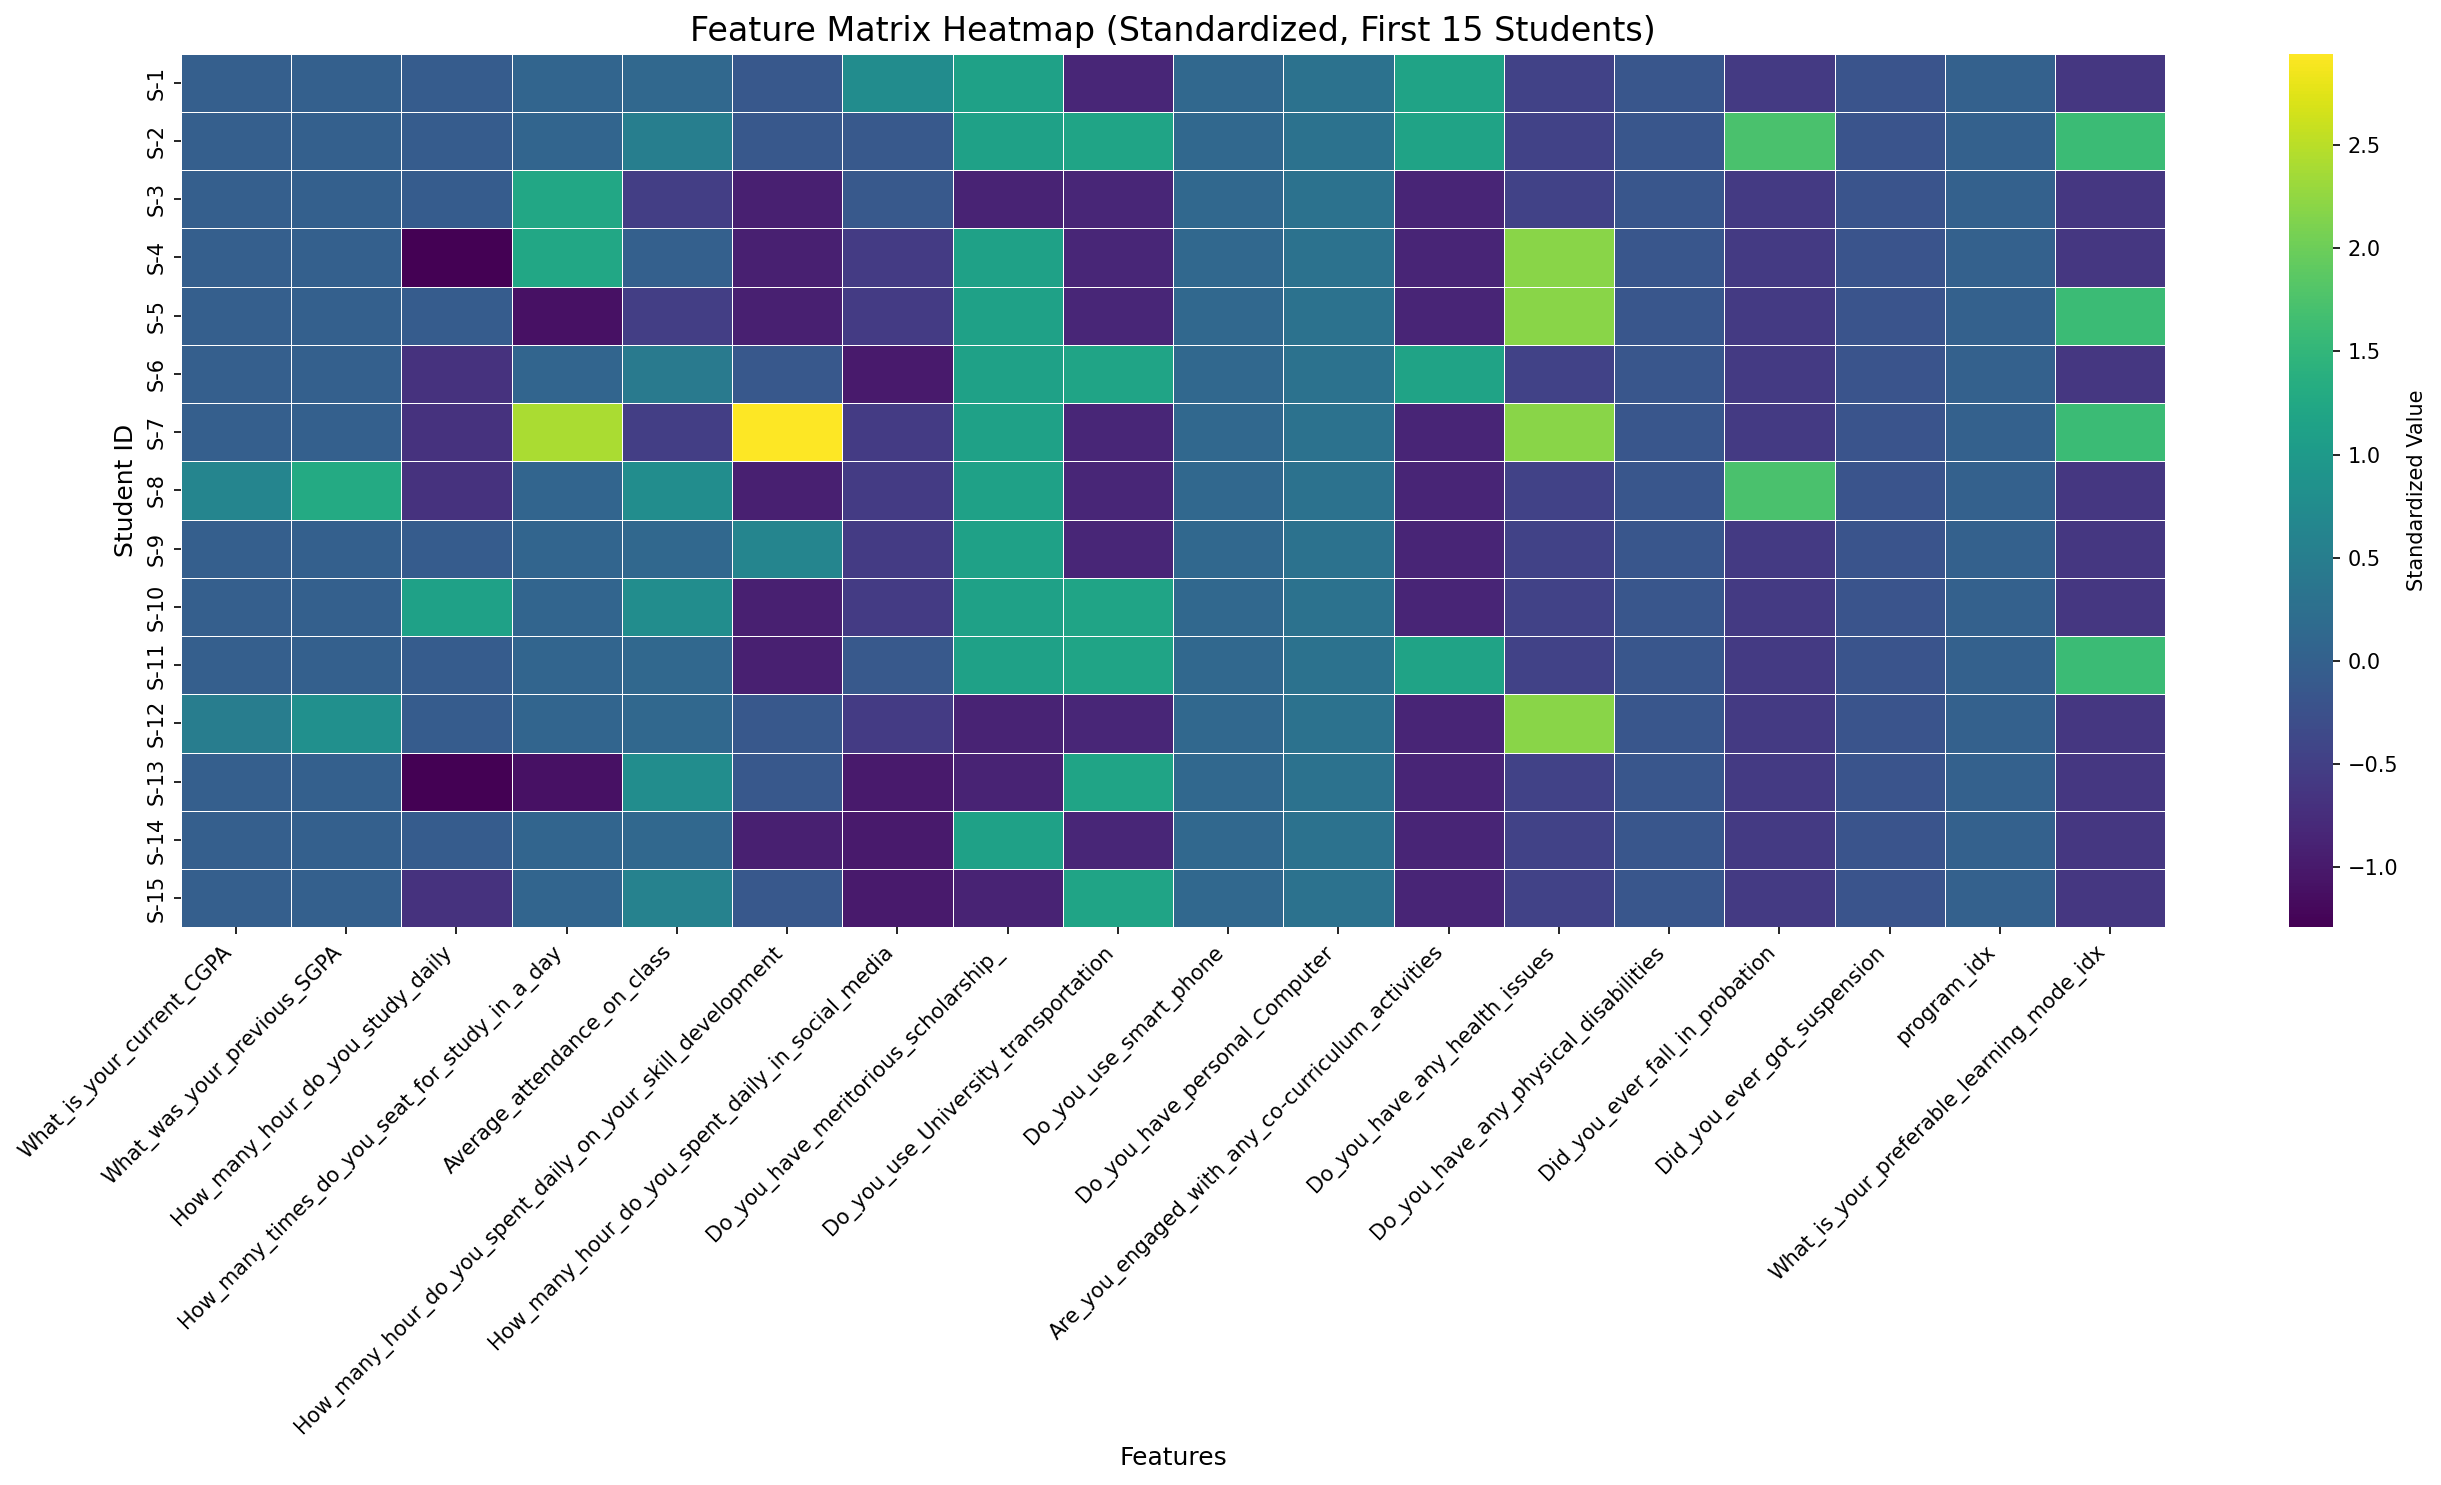

In [ ]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)

feature_matrix_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=df_nodes['id']
)


plt.figure(figsize=(18, 10), dpi=150)

sns.heatmap(
    feature_matrix_df.iloc[:15],   # fewer rows = clearer
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Standardized Value"}
)

plt.title("Feature Matrix Heatmap (Standardized, First 15 Students)", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Student ID", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
torch.save(model.state_dict(), "graphsage_model.pt")

import pickle
with open("features.pkl", "wb") as f:
    pickle.dump(feature_matrix_df, f)


In [ ]:
from google.colab import files

files.download("graphsage_model.pt")
files.download("features.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# query section

In [ ]:
!pip install neo4j
import pandas as pd
from neo4j import GraphDatabase

In [ ]:
from neo4j import GraphDatabase, graph
import pandas as pd

def execute_cypher_query(query, driver):
    results_list = []
    has_graph_elements = False

    with driver.session() as session:
        result = session.run(query)
        for record in result:
            record_dict = record.data()
            results_list.append(record_dict)
            for value in record_dict.values():
                if isinstance(value, graph.Node) or isinstance(value, graph.Relationship):
                    has_graph_elements = True
                    break
            if has_graph_elements: # Optimization: if we already found graph elements, no need to check further for this record
                continue

    if has_graph_elements:
        nodes = {}
        relationships = []

        for record_dict in results_list:
            for value in record_dict.values():
                if isinstance(value, graph.Node):
                    node_id = value.element_id
                    if node_id not in nodes:
                        nodes[node_id] = {
                            "id": value.id, # Neo4j internal id
                            "element_id": value.element_id,
                            "labels": list(value.labels),
                            "properties": dict(value.items())
                        }
                elif isinstance(value, graph.Relationship):
                    relationships.append({
                        "id": value.id,
                        "element_id": value.element_id,
                        "type": value.type,
                        "start_node_id": value.start_node.element_id,
                        "end_node_id": value.end_node.element_id,
                        "properties": dict(value.items())
                    })
                    # Ensure start and end nodes are also captured
                    if value.start_node.element_id not in nodes:
                        nodes[value.start_node.element_id] = {
                            "id": value.start_node.id,
                            "element_id": value.start_node.element_id,
                            "labels": list(value.start_node.labels),
                            "properties": dict(value.start_node.items())
                        }
                    if value.end_node.element_id not in nodes:
                        nodes[value.end_node.element_id] = {
                            "id": value.end_node.id,
                            "element_id": value.end_node.element_id,
                            "labels": list(value.end_node.labels),
                            "properties": dict(value.end_node.items())
                        }
        return {"nodes": list(nodes.values()), "relationships": relationships}
    else:
        if results_list:
            return pd.DataFrame(results_list)
        else:
            return pd.DataFrame()

print("The `execute_cypher_query` function has been defined.")

The `execute_cypher_query` function has been defined.


In [ ]:
from neo4j import GraphDatabase, graph
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def execute_cypher_query(query, driver):
    results_list = []
    has_graph_elements = False

    with driver.session() as session:
        result = session.run(query)
        for record in result:
            record_dict = record.data()
            results_list.append(record_dict)
            for value in record_dict.values():
                if isinstance(value, graph.Node) or isinstance(value, graph.Relationship):
                    has_graph_elements = True
                    break
            if has_graph_elements: # Optimization: if we already found graph elements, no need to check further for this record
                continue

    if has_graph_elements:
        nodes = {}
        relationships = []

        for record_dict in results_list:
            for value in record_dict.values():
                if isinstance(value, graph.Node):
                    node_id = value.element_id
                    if node_id not in nodes:
                        nodes[node_id] = {
                            "id": value.id, # Neo4j internal id
                            "element_id": value.element_id,
                            "labels": list(value.labels),
                            "properties": dict(value.items())
                        }
                elif isinstance(value, graph.Relationship):
                    relationships.append({
                        "id": value.id,
                        "element_id": value.element_id,
                        "type": value.type,
                        "start_node_id": value.start_node.element_id,
                        "end_node_id": value.end_node.element_id,
                        "properties": dict(value.items())
                    })
                    # Ensure start and end nodes are also captured
                    if value.start_node.element_id not in nodes:
                        nodes[value.start_node.element_id] = {
                            "id": value.start_node.id,
                            "element_id": value.start_node.element_id,
                            "labels": list(value.start_node.labels),
                            "properties": dict(value.start_node.items())
                        }
                    if value.end_node.element_id not in nodes:
                        nodes[value.end_node.element_id] = {
                            "id": value.end_node.id,
                            "element_id": value.end_node.element_id,
                            "labels": list(value.end_node.labels),
                            "properties": dict(value.end_node.items())
                        }
        return {"nodes": list(nodes.values()), "relationships": relationships}
    else:
        if results_list:
            return pd.DataFrame(results_list)
        else:
            return pd.DataFrame()

def display_graph(graph_data):
    G = nx.DiGraph()

    # Add nodes
    for node in graph_data['nodes']:
        G.add_node(node['element_id'], **node['properties'])

    # Add relationships as edges
    for rel in graph_data['relationships']:
        G.add_edge(rel['start_node_id'], rel['end_node_id'], label=rel['type'], **rel['properties'])

    # Prepare node colors based on role
    node_colors = []
    for node_id in G.nodes():
        role = G.nodes[node_id].get('role')
        if role == 'Tutor':
            node_colors.append('skyblue')
        elif role == 'Tutee':
            node_colors.append('lightcoral')
        else:
            node_colors.append('lightgray') # Default color for nodes without a specific role

    # Prepare node labels (using 'id' property)
    node_labels = {node_id: G.nodes[node_id].get('id', node_id) for node_id in G.nodes()}

    # Prepare edge labels (using 'label' property, which stores relationship type)
    edge_labels = nx.get_edge_attributes(G, 'label')

    # Set up the plot
    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(G, k=0.15, iterations=50) # Increase iterations for better layout spreading

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1.5)

    # Draw node labels
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_color='black')

    # Draw edge labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

    plt.title('Neo4j Graph Visualization', size=18)
    plt.axis('off')
    plt.show()

print("The `execute_cypher_query` and `display_graph` functions have been defined.")

The `execute_cypher_query` and `display_graph` functions have been defined.


In [ ]:
!pip install networkx matplotlib

from neo4j import GraphDatabase, graph
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def execute_cypher_query(query, driver):
    raw_records = []
    dict_records = []
    has_graph_elements = False

    with driver.session() as session:
        result = session.run(query)
        for record in result:
            is_graph_record = False
            for value in record.values():
                if isinstance(value, graph.Node) or isinstance(value, graph.Relationship):
                    is_graph_record = True
                    has_graph_elements = True
                    break

            if is_graph_record:
                raw_records.append(record)
            else:
                dict_records.append(record.data())

    if has_graph_elements:
        nodes = {}
        relationships = []

        for record in raw_records:
            for value in record.values():
                if isinstance(value, graph.Node):
                    node_id = value.element_id
                    if node_id not in nodes:
                        nodes[node_id] = {
                            "id": value.id,
                            "element_id": value.element_id,
                            "labels": list(value.labels),
                            "properties": dict(value.items())
                        }
                elif isinstance(value, graph.Relationship):
                    relationships.append({
                        "id": value.id,
                        "element_id": value.element_id,
                        "type": value.type,
                        "start_node_id": value.start_node.element_id,
                        "end_node_id": value.end_node.element_id,
                        "properties": dict(value.items())
                    })
                    if value.start_node.element_id not in nodes:
                        nodes[value.start_node.element_id] = {
                            "id": value.start_node.id,
                            "element_id": value.start_node.element_id,
                            "labels": list(value.start_node.labels),
                            "properties": dict(value.start_node.items())
                        }
                    if value.end_node.element_id not in nodes:
                        nodes[value.end_node.element_id] = {
                            "id": value.end_node.id,
                            "element_id": value.end_node.element_id,
                            "labels": list(value.end_node.labels),
                            "properties": dict(value.end_node.items())
                        }
        return {"nodes": list(nodes.values()), "relationships": relationships}
    else:
        if dict_records:
            return pd.DataFrame(dict_records)
        else:
            return pd.DataFrame()

def display_graph(graph_data):
    G = nx.DiGraph()

    # Add nodes
    for node in graph_data['nodes']:
        G.add_node(node['element_id'], **node['properties'])

    # Add relationships as edges
    for rel in graph_data['relationships']:
        G.add_edge(rel['start_node_id'], rel['end_node_id'], label=rel['type'], **rel['properties'])

    # Prepare node colors based on role
    node_colors = []
    for node_id in G.nodes():
        role = G.nodes[node_id].get('role')
        if role == 'Tutor':
            node_colors.append('skyblue')
        elif role == 'Tutee':
            node_colors.append('lightcoral')
        else:
            node_colors.append('lightgray') # Default color for nodes without a specific role

    # Prepare node labels (using 'id' property)
    node_labels = {node_id: G.nodes[node_id].get('id', node_id) for node_id in G.nodes()}

    # Prepare edge labels (using 'label' property, which stores relationship type)
    edge_labels = nx.get_edge_attributes(G, 'label')

    # Set up the plot
    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(G, k=0.15, iterations=50) # Increase iterations for better layout spreading

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1.5)

    # Draw node labels
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_color='black')

    # Draw edge labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

    plt.title('Neo4j Graph Visualization', size=18)
    plt.axis('off')
    plt.show()

print("The `execute_cypher_query` and `display_graph` functions have been defined and necessary libraries installed.")

The `execute_cypher_query` and `display_graph` functions have been defined and necessary libraries installed.


In [ ]:
!pip install pyvis


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.0 MB/s eta 0:00:00


In [ ]:
# ===============================
# 0. INSTALL REQUIRED PACKAGE (RUN ONCE)
# ===============================
# Uncomment and run if pyvis is not installed
# !pip install pyvis neo4j pandas

from neo4j import GraphDatabase
import pandas as pd
from pyvis.network import Network

# ===============================
# 1. Neo4j Connection Details
# ===============================
NEO4J_URI = "neo4j+s://1ae5dd78.databases.neo4j.io"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "Qfquqk94yxyCZkRg2hkI67kcJUmd0jg_RMZ4Gv_eRnQ"

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD)
)

print("✅ Neo4j connected")

# ===============================
# 2. Execute Cypher Query
# ===============================
def execute_cypher_query(query, driver):
    with driver.session() as session:
        result = session.run(query)
        records = result.data()

        if not records:
            return None, False

        # Detect graph objects
        has_graph = False
        for record in records:
            for value in record.values():
                if hasattr(value, "labels") or hasattr(value, "start_node") or hasattr(value, "nodes"):
                    has_graph = True
                    break

        if has_graph:
            return records, True
        else:
            return pd.DataFrame(records), False

# ===============================
# 3. Graph Visualization (FINAL FIX)
# ===============================
def display_graph(records):
    net = Network(
        height="600px",
        width="100%",
        notebook=True,
        bgcolor="white",
        cdn_resources="in_line"  # FIXES Jupyter display issues
    )

    added_nodes = set()

    for record in records:
        for value in record.values():

            # ---- NODE ----
            if hasattr(value, "labels"):
                nid = value.element_id
                if nid not in added_nodes:
                    net.add_node(
                        nid,
                        label=value.get("id", nid),
                        title=str(dict(value))
                    )
                    added_nodes.add(nid)

            # ---- RELATIONSHIP ----
            elif hasattr(value, "start_node"):
                start = value.start_node.element_id
                end = value.end_node.element_id

                if start not in added_nodes:
                    net.add_node(start, label=value.start_node.get("id", start))
                    added_nodes.add(start)

                if end not in added_nodes:
                    net.add_node(end, label=value.end_node.get("id", end))
                    added_nodes.add(end)

                net.add_edge(start, end, label=value.type)

            # ---- PATH ----
            elif hasattr(value, "nodes"):
                for node in value.nodes:
                    nid = node.element_id
                    if nid not in added_nodes:
                        net.add_node(
                            nid,
                            label=node.get("id", nid),
                            title=str(dict(node))
                        )
                        added_nodes.add(nid)

                for rel in value.relationships:
                    net.add_edge(
                        rel.start_node.element_id,
                        rel.end_node.element_id,
                        label=rel.type
                    )

    net.show("neo4j_graph.html")
    print("🕸️ Graph saved as neo4j_graph.html")

# ===============================
# 4. Run ONE Query Only
# ===============================
query = input("Enter Cypher query:\n")

try:
    result, is_graph = execute_cypher_query(query, driver)

    if result is None:
        print("⚠️ Query executed, but no results found.")

    elif is_graph:
        print("🕸️ Graph Result")
        display_graph(result)

    else:
        print("📊 Tabular Result")
        display(result)

except Exception as e:
    print("❌ Error:", e)

finally:
    driver.close()
    print("🔒 Neo4j connection closed")


✅ Neo4j connected
Enter Cypher query:
MATCH (s:Student {id: "S-1"})--(other:Student) RETURN s.id AS StudentID, COUNT(other) AS TotalConnections;
📊 Tabular Result


,StudentID,TotalConnections
0,S-1,490


🔒 Neo4j connection closed


In [ ]:
from neo4j import GraphDatabase
import pandas as pd
from pyvis.network import Network
from IPython.display import display, HTML

# ===============================
# 1. Neo4j Connection
# ===============================
NEO4J_URI = "neo4j+s://1ae5dd78.databases.neo4j.io"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "Qfquqk94yxyCZkRg2hkI67kcJUmd0jg_RMZ4Gv_eRnQ"

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD)
)

print("✅ Neo4j connected")

# ===============================
# 2. Execute Query
# ===============================
def execute_query(query):
    with driver.session() as session:
        result = session.run(query)
        return list(result)

# ===============================
# 3. Graph Visualization
# ===============================
def display_graph(records):
    net = Network(
        height="600px",
        width="100%",
        bgcolor="white",
        font_color="black",
        cdn_resources="in_line"
    )

    added_nodes = set()

    for record in records:
        for value in record.values():

            # ---- NODE ----
            if hasattr(value, "element_id"):
                node_id = value.element_id
                label = value.get("id", value.element_id)

                if node_id not in added_nodes:
                    net.add_node(
                        node_id,
                        label=label,
                        title=str(dict(value)),
                        shape="dot"
                    )
                    added_nodes.add(node_id)

            # ---- RELATIONSHIP ----
            if hasattr(value, "start_node"):
                start_id = value.start_node.element_id
                end_id = value.end_node.element_id

                if start_id not in added_nodes:
                    net.add_node(start_id, label=value.start_node.get("id", start_id))
                    added_nodes.add(start_id)

                if end_id not in added_nodes:
                    net.add_node(end_id, label=value.end_node.get("id", end_id))
                    added_nodes.add(end_id)

                net.add_edge(
                    start_id,
                    end_id,
                    label=value.type
                )

    net.show("neo4j_graph.html")
    display(HTML("neo4j_graph.html"))

# ===============================
# 4. Run One Query
# ===============================
query = input("Enter Cypher query:\n")

try:
    records = execute_query(query)

    if not records:
        print("⚠️ No results found")

    # Detect graph result
    has_graph = any(
        any(hasattr(v, "element_id") or hasattr(v, "start_node") for v in r.values())
        for r in records
    )

    if has_graph:
        print("🕸️ Graph Result")
        display_graph(records)
    else:
        print("📊 Tabular Result")
        df = pd.DataFrame([r.data() for r in records])
        display(df)

except Exception as e:
    print("❌ Error:", e)

finally:
    driver.close()
    print("🔒 Neo4j connection closed")


✅ Neo4j connected
Enter Cypher query:
MATCH (s:Student {id: "S-1"})-[r]->(other) RETURN s, r, other;
🕸️ Graph Result
neo4j_graph.html
❌ Error: 'NoneType' object has no attribute 'render'
🔒 Neo4j connection closed


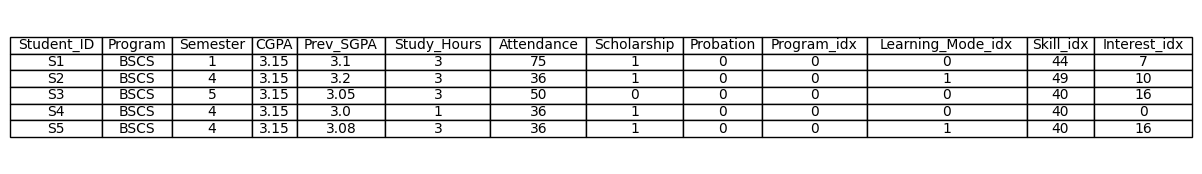

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define your dataset
data = {
    "Student_ID": ["S1", "S2", "S3", "S4", "S5"],
    "Program": ["BSCS"]*5,
    "Semester": [1,4,5,4,4],
    "CGPA": [3.15]*5,
    "Prev_SGPA": [3.10, 3.20, 3.05, 3.00, 3.08],
    "Study_Hours": [3,3,3,1,3],
    "Attendance": [75,36,50,36,36],
    "Scholarship": [1,1,0,1,1],
    "Probation": [0,0,0,0,0],
    "Program_idx": [0,0,0,0,0],
    "Learning_Mode_idx": [0,1,0,0,1],
    "Skill_idx": [44,49,40,40,40],
    "Interest_idx": [7,10,16,0,16]
}

df = pd.DataFrame(data)

# Create figure and hide axes
fig, ax = plt.subplots(figsize=(12,2)) # width x height in inches
ax.axis('off')

# Create table
tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.auto_set_column_width(col=list(range(len(df.columns))))

# Save as PNG
plt.savefig("sample_student_dataset.png", bbox_inches='tight', dpi=300)
plt.show()
